### 📊 EDA 레포트 · J.Son

#### IBM HR 데이터 기반 직원 이직 요인 탐색적 분석

EDA(Exploratory Data Analysis, 탐색적 데이터 분석)는 데이터를 처음 접했을 때 **구조를 이해하고, 패턴을 발견하며, 문제점을 파악**하는 과정을 체계적으로 문서화하는 작업이다.  
본 레포트는 IBM HR 데이터를 바탕으로 직원 이직(`Attrition`)과 관련된 특성을 탐색적으로 분석한 결과를 정리한 것이다.

#### 1. 🎯 프로젝트 개요

- **목적**: 직원 이직은 기업의 채용·교육 비용 증가, 숙련 인력 이탈에 따른 업무 연속성 저하, 조직 운영 안정성 저하를 초래할 수 있는 인사관리상의 주요 pain point이다. 본 분석은 직원 이직 여부(`Attrition`)와 관련된 주요 변수의 패턴을 탐색적으로 파악하고, 향후 이직 예측 및 인사관리 개선에 활용 가능한 기초 인사이트를 도출하는 것을 목적으로 한다.
- **데이터 출처**: Kaggle - IBM HR Analytics Employee Attrition & Performance
- **데이터 구성**: 총 35개 컬럼, 1470개 행
- **분석 대상**: 직원의 인구통계적 특성, 근무 조건, 소득, 근속기간, 직무 관련 정보와 이직 여부(`Attrition`)

> 포인트: 이 분석은 “왜 직원이 회사를 떠나는가?”를 데이터로 이해하려는 시도이다.

#### 2. 🗂 데이터 기본 정보

- **총 데이터 수**: 1470개
- **컬럼 수**: 35개
- **타깃 변수**: `Attrition`
- **주요 수치형 변수**: `Age`, `MonthlyIncome`, `DailyRate`, `DistanceFromHome`, `YearsAtCompany`, `TotalWorkingYears`
- **주요 범주형 변수**: `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`
- **결측치**: 없음
- **참고 사항**: `EmployeeCount`, `Over18`, `StandardHours`는 상수값만 가지는 컬럼으로 확인됨

본 데이터는 수치형 변수와 범주형 변수가 함께 포함된 구조로, **이직 여부를 기준으로 한 그룹 비교 분석**에 적합하다.

#### 3. 📌 기술 통계 요약

##### 3.1 수치형 변수

| 컬럼명 | 평균 | 중앙값 | 표준편차 | 최솟값 | 최댓값 |
|--------|------|--------|----------|--------|--------|
| Age | 36.92 | 36.00 | 9.14 | 18 | 60 |
| MonthlyIncome | 6502.93 | 4919.00 | 4707.96 | 1009 | 19999 |
| DistanceFromHome | 9.19 | 7.00 | 8.11 | 1 | 29 |
| YearsAtCompany | 7.01 | 5.00 | 6.13 | 0 | 40 |
| TotalWorkingYears | 11.28 | 10.00 | 7.78 | 0 | 40 |

##### 3.2 범주형 변수

| 컬럼명 | 고유값 | 최빈값 | 분포 |
|--------|--------|--------|------|
| Attrition | 2개 | No | No: 83.9%, Yes: 16.1% |
| Gender | 2개 | Male | Male: 60.0%, Female: 40.0% |
| OverTime | 2개 | No | No: 71.7%, Yes: 28.3% |
| Department | 3개 | Research & Development | Research & Development: 65.4%, Sales: 30.3%, Human Resources: 4.3% |
| JobRole | 9개 | Sales Executive | Sales Executive: 22.2%, Research Scientist: 19.9%, Laboratory Technician: 17.6%, Manufacturing Director: 9.9%, Healthcare Representative: 8.9%, Manager: 6.9%, Sales Representative: 5.6%, Research Director: 5.4%, Human Resources: 3.5% |

##### 3.3 해석

- `Age`는 평균 36.92세, 중앙값 36세로 나타나 전반적으로 **30대 중반 중심의 분포**를 보인다.
- `MonthlyIncome`은 평균과 중앙값 차이가 커 일부 고소득자의 영향이 존재할 가능성이 있다.
- `YearsAtCompany`와 `TotalWorkingYears`는 최소값과 최대값 차이가 커 **근속기간 및 전체 경력의 편차**가 큰 편이다.
- `Attrition`은 **직원의 이직 여부**를 의미하며, `Yes`는 이직, `No`는 비이직을 뜻한다.
- 전체 직원 중 비이직자 비율이 더 높아 **이직 여부에 다소 클래스 불균형**이 존재한다.
- `Department`는 Research & Development 비중이 가장 높다.

> 포인트: 이 데이터는 “누가 더 많이 떠나는가”를 비교하기에 적합한 구조를 가지고 있다.

#### 4. 🔍 결측치 및 이상치 탐색

- 전체 컬럼 확인 결과 **결측치는 발견되지 않았다.**
- `MonthlyIncome`, `DistanceFromHome`, `YearsAtCompany`, `TotalWorkingYears` 등에 대해 boxplot을 활용하여 이상치 여부를 확인하였다.
- 소득 및 근속기간 변수의 큰 값은 실제 장기근속자 또는 고소득자일 가능성이 있으므로, 단순 제거보다 **분포 특성을 고려한 해석**이 필요하다.
- `EmployeeCount`, `Over18`, `StandardHours`는 정보량이 없는 상수 컬럼으로 분석 제외 후보로 판단된다.

##### 4.1 이상치 확인용 박스플롯

<img src="eda/images/06_numeric_boxplots.png" width="620">

> 포인트: 값이 크다고 무조건 이상치로 제거하기보다, 실제 고소득·장기근속자의 가능성을 함께 고려해야 한다.

#### 5. 📈 변수 간 관계 분석

##### 5.1 이직 여부 분포

`Attrition Distribution`은 **전체 직원 중 이직자와 비이직자의 비율 분포**를 나타낸다.  
그래프를 통해 전체 데이터에서 비이직자(`No`)가 더 많은 비중을 차지하고 있음을 확인할 수 있다.

<img src="eda/images/01_attrition_distribution.png" width="480">

##### 5.2 초과근무 여부에 따른 이직률

- 초과근무를 하지 않는 집단의 이직률은 **10.4%**였다.
- 초과근무를 하는 집단의 이직률은 **30.5%**로, 초과근무 집단에서 이직 비율이 훨씬 높게 나타났다.

이 그래프는 **초과근무 여부에 따라 이직률이 어떻게 달라지는지**를 보여준다.

<img src="eda/images/02_overtime_attrition_rate.png" width="480">

> **해석**: `OverTime`은 이직 설명 변수로서 매우 중요한 후보라고 볼 수 있다.

##### 5.3 이직 여부에 따른 월소득 비교

`Attrition별 MonthlyIncome 박스플롯`은 **이직한 직원과 이직하지 않은 직원의 월소득 분포를 비교한 그래프**이다.

- 비이직자 평균 월소득은 **6832.74**
- 이직자 평균 월소득은 **4787.09**

이직자 집단의 평균 월소득이 더 낮아, 소득 수준과 이직 여부 간 차이가 존재할 가능성을 확인하였다.

<img src="eda/images/03_monthlyincome_boxplot.png" width="480">

> **해석**: 월소득 수준이 낮은 집단에서 이직이 더 많이 나타날 가능성을 시사한다.

##### 5.4 이직 여부에 따른 평균값 비교

`Attrition별 평균 비교`는 **이직자 집단과 비이직자 집단의 평균값을 비교한 결과**이다.

- 비이직자의 평균 근속기간은 **7.37년**
- 이직자의 평균 근속기간은 **5.13년**

이직자 집단의 근속기간이 더 짧아, **근속기간과 이직 간 관련성**을 시사한다.

> **해석**: 회사에 오래 근무할수록 이직 가능성이 낮아질 수 있다.

##### 5.5 직무별 이직률 비교

- `Sales Representative`의 이직률이 **39.8%**로 가장 높았다.
- 그 다음으로 `Laboratory Technician` **23.9%**, `Human Resources` **23.1%** 순으로 나타났다.
- 반면 `Research Director` **2.5%**, `Manager` **4.9%**는 상대적으로 낮은 이직률을 보였다.

이 그래프는 **직무(JobRole)에 따라 이직률 차이가 존재하는지**를 보여준다.

<img src="eda/images/04_jobrole_attrition_rate.png" width="700">

> **해석**: 특정 직무군에서 이직이 집중될 가능성이 있으며, 직무 특성에 따른 관리 전략이 필요하다.

##### 5.6 워라밸 및 직무만족도와 이직률

- `WorkLifeBalance`가 1점인 집단의 이직률은 **31.2%**로 가장 높게 나타났다.
- `JobSatisfaction`이 1점인 집단의 이직률은 **22.8%**
- `JobSatisfaction`이 4점인 집단은 **11.3%**

즉, 워라밸과 직무만족도가 낮을수록 이직률이 높아지는 경향이 확인되었다.

> **해석**: 단순 급여뿐 아니라 **직무 만족과 삶의 질**도 이직에 중요한 영향을 미칠 수 있다.

##### 5.7 수치형 변수 상관관계

- `Attrition`과 음의 상관이 상대적으로 크게 나타난 변수는 `TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, `MonthlyIncome`, `Age` 등이었다.
- 이는 경력, 직급, 소득 수준이 높을수록 이직 가능성이 상대적으로 낮아질 수 있음을 시사한다.

아래 히트맵은 **주요 수치형 변수 간 상관관계와 이직 여부(`AttritionFlag`)와의 관계**를 시각적으로 보여준다.

<img src="eda/images/05_correlation_heatmap.png" width="700">

> **해석**: 이직은 단일 변수보다는 **경력, 소득, 직급, 근속기간 등 여러 요인이 함께 작용하는 현상**으로 볼 수 있다.

#### 6. 🛠 파생 변수 생성 및 전처리 제안

- `Age` → 연령대 구간화(20대, 30대, 40대 이상)
- `YearsAtCompany` → 근속기간 구간화(`Short`, `Medium`, `Long`)
- `MonthlyIncome` → 분포 왜도가 큰 경우 로그 변환 검토
- 범주형 변수(`BusinessTravel`, `Department`, `JobRole`, `MaritalStatus`, `OverTime`) → 향후 모델링을 위해 인코딩 필요
- 상수 컬럼(`EmployeeCount`, `Over18`, `StandardHours`) → 제거 후보

> 향후 예측 모델을 구축할 경우, 위와 같은 전처리를 통해 변수 활용도를 높일 수 있다.

#### 7. ✅ 요약 및 인사이트

- 초과근무 집단의 이직률이 더 높게 나타나 `OverTime`은 핵심 설명 변수로 활용 가능하다.
- 이직자 집단은 비이직자 집단에 비해 평균 월소득과 근속기간이 더 낮았다.
- `Sales Representative`, `Laboratory Technician`, `Human Resources` 직무에서 상대적으로 높은 이직률이 관찰되었다.
- 워라밸과 직무만족도가 낮을수록 이직률이 높아지는 경향이 나타났다.
- 향후 이직 예측 모델링을 위해 범주형 변수 인코딩, 상수 컬럼 제거, 수치형 변수 분포 점검이 필요하다.

#### 8. 💡 최종 결론

본 EDA를 통해 직원 이직은 단순히 개인 특성 하나로 설명되는 것이 아니라, **초과근무, 소득 수준, 근속기간, 직무 특성, 워라밸, 직무만족도** 등 다양한 요인이 복합적으로 작용한 결과임을 확인하였다.  
따라서 향후 기업의 인사관리 전략에서는 단순 보상체계뿐 아니라 **근무환경 개선, 직무별 맞춤 관리, 장기근속 유도 방안**까지 함께 고려할 필요가 있다.

##### ⬇️ 사용 코드

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# ---------------------------
# macOS 한글 폰트 설정
# ---------------------------
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------
# 경로 설정
# ---------------------------
data_path = Path("./data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
text_dir = Path("./eda/text")
text_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------
# 데이터 로딩
# ---------------------------
df = pd.read_csv(data_path)

# ---------------------------
# 데이터 기본 정보 추출
# ---------------------------
shape_text = f"행, 열: {df.shape}"

columns_text = "\n컬럼명:\n" + str(df.columns.tolist())

dtypes_text = "\n데이터 타입:\n" + str(df.dtypes)

nulls_text = "\n결측치 개수:\n" + str(df.isnull().sum())

constant_cols = [col for col in df.columns if df[col].nunique() == 1]
constant_text = "\n상수 컬럼:\n" + str(constant_cols)

# 출력
print(shape_text)
print(columns_text)
print(dtypes_text)
print(nulls_text)
print(constant_text)

# df.info()는 문자열 캡처해서 저장
from io import StringIO
buffer = StringIO()
df.info(buf=buffer)
info_text = "\ndf.info():\n" + buffer.getvalue()

print(info_text)

# ---------------------------
# 텍스트 파일 저장
# ---------------------------
output_text = "\n".join([
    shape_text,
    columns_text,
    dtypes_text,
    nulls_text,
    constant_text,
    info_text
])

output_path = text_dir / "02_data_basic_info.txt"
output_path.write_text(output_text, encoding="utf-8")

print(f"\n저장 완료: {output_path.resolve()}")

행, 열: (1470, 35)

컬럼명:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

데이터 타입:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
Environme

In [2]:
# 3) 기술 통계 요약 코드 - 수치형 변수

# 저장 경로
text_dir = Path("./eda/text")
text_dir.mkdir(parents=True, exist_ok=True)

# 수치형 변수 선택
numeric_cols = ["Age", "MonthlyIncome", "DistanceFromHome", "YearsAtCompany", "TotalWorkingYears"]

# 기술 통계 계산
numeric_summary = df[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T.round(2)
numeric_summary.columns = ["평균", "중앙값", "표준편차", "최솟값", "최댓값"]

# 출력
print("\n수치형 변수 기술통계")
print(numeric_summary)

# CSV 저장
numeric_summary.to_csv(text_dir / "03_numeric_summary.csv", encoding="utf-8-sig")

# markdown 표 수동 생성
md_lines = []
md_lines.append("### 수치형 변수\n")
md_lines.append("| 컬럼명 | 평균 | 중앙값 | 표준편차 | 최솟값 | 최댓값 |")
md_lines.append("|--------|------|--------|----------|--------|--------|")

for idx, row in numeric_summary.iterrows():
    md_lines.append(
        f"| {idx} | {row['평균']:.2f} | {row['중앙값']:.2f} | {row['표준편차']:.2f} | {row['최솟값']:.0f} | {row['최댓값']:.0f} |"
    )

(text_dir / "03_numeric_summary.md").write_text(
    "\n".join(md_lines),
    encoding="utf-8"
)

print("\n저장 완료:")
print(text_dir / "03_numeric_summary.csv")
print(text_dir / "03_numeric_summary.md")


수치형 변수 기술통계
                        평균     중앙값     표준편차     최솟값      최댓값
Age                  36.92    36.0     9.14    18.0     60.0
MonthlyIncome      6502.93  4919.0  4707.96  1009.0  19999.0
DistanceFromHome      9.19     7.0     8.11     1.0     29.0
YearsAtCompany        7.01     5.0     6.13     0.0     40.0
TotalWorkingYears    11.28    10.0     7.78     0.0     40.0

저장 완료:
eda/text/03_numeric_summary.csv
eda/text/03_numeric_summary.md


In [3]:
# 4) 범주형 변수 분포 추출 코드

# 저장 경로
text_dir = Path("./eda/text")
text_dir.mkdir(parents=True, exist_ok=True)

# 범주형 변수 분포 계산
attrition_dist = (df["Attrition"].value_counts(normalize=True) * 100).round(1)
gender_dist = (df["Gender"].value_counts(normalize=True) * 100).round(1)
overtime_dist = (df["OverTime"].value_counts(normalize=True) * 100).round(1)
department_dist = (df["Department"].value_counts(normalize=True) * 100).round(1)
jobrole_dist = (df["JobRole"].value_counts(normalize=True) * 100).round(1)

# 출력
print("\nAttrition 분포(%)")
print(attrition_dist)

print("\nGender 분포(%)")
print(gender_dist)

print("\nOverTime 분포(%)")
print(overtime_dist)

print("\nDepartment 분포(%)")
print(department_dist)

print("\nJobRole 분포(%)")
print(jobrole_dist)

# 표용 요약 데이터프레임 생성
cat_summary = pd.DataFrame({
    "고유값": [
        df["Attrition"].nunique(),
        df["Gender"].nunique(),
        df["OverTime"].nunique(),
        df["Department"].nunique(),
        df["JobRole"].nunique()
    ],
    "최빈값": [
        df["Attrition"].mode()[0],
        df["Gender"].mode()[0],
        df["OverTime"].mode()[0],
        df["Department"].mode()[0],
        df["JobRole"].mode()[0]
    ],
    "분포": [
        f"No: {attrition_dist['No']}%, Yes: {attrition_dist['Yes']}%",
        f"Male: {gender_dist['Male']}%, Female: {gender_dist['Female']}%",
        f"No: {overtime_dist['No']}%, Yes: {overtime_dist['Yes']}%",
        ", ".join([f"{idx}: {val}%" for idx, val in department_dist.items()]),
        ", ".join([f"{idx}: {val}%" for idx, val in jobrole_dist.items()])
    ]
}, index=["Attrition", "Gender", "OverTime", "Department", "JobRole"])

# CSV 저장
cat_summary.to_csv(text_dir / "04_categorical_summary.csv", encoding="utf-8-sig")

# markdown 표 수동 생성
md_lines = []
md_lines.append("### 범주형 변수\n")
md_lines.append("| 컬럼명 | 고유값 | 최빈값 | 분포 |")
md_lines.append("|--------|--------|--------|------|")

for idx, row in cat_summary.iterrows():
    md_lines.append(
        f"| {idx} | {row['고유값']} | {row['최빈값']} | {row['분포']} |"
    )

(text_dir / "04_categorical_summary.md").write_text(
    "\n".join(md_lines),
    encoding="utf-8"
)

# 상세 분포 텍스트 저장
detail_text = []
detail_text.append("[Attrition 분포(%)]\n" + attrition_dist.to_string())
detail_text.append("\n[Gender 분포(%)]\n" + gender_dist.to_string())
detail_text.append("\n[OverTime 분포(%)]\n" + overtime_dist.to_string())
detail_text.append("\n[Department 분포(%)]\n" + department_dist.to_string())
detail_text.append("\n[JobRole 분포(%)]\n" + jobrole_dist.to_string())

(text_dir / "04_categorical_distribution_detail.txt").write_text(
    "\n".join(detail_text),
    encoding="utf-8"
)

print("\n저장 완료:")
print(text_dir / "04_categorical_summary.csv")
print(text_dir / "04_categorical_summary.md")
print(text_dir / "04_categorical_distribution_detail.txt")


Attrition 분포(%)
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

Gender 분포(%)
Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64

OverTime 분포(%)
OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64

Department 분포(%)
Department
Research & Development    65.4
Sales                     30.3
Human Resources            4.3
Name: proportion, dtype: float64

JobRole 분포(%)
JobRole
Sales Executive              22.2
Research Scientist           19.9
Laboratory Technician        17.6
Manufacturing Director        9.9
Healthcare Representative     8.9
Manager                       6.9
Sales Representative          5.6
Research Director             5.4
Human Resources               3.5
Name: proportion, dtype: float64

저장 완료:
eda/text/04_categorical_summary.csv
eda/text/04_categorical_summary.md
eda/text/04_categorical_distribution_detail.txt


전체 결측치 수: 0

컬럼별 결측치 개수:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentR

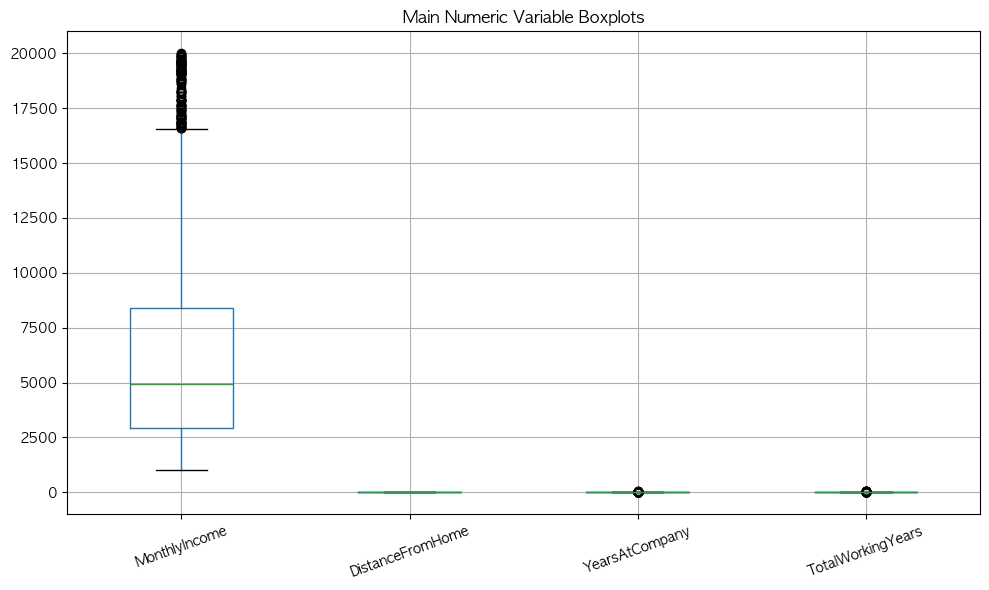


저장 완료:
eda/text/05_missing_value_summary.txt
eda/images/06_numeric_boxplots.png


In [4]:
# 5) 결측치 및 이상치 확인 코드

# 저장 경로
text_dir = Path("./eda/text")
img_dir = Path("./eda/images")
text_dir.mkdir(parents=True, exist_ok=True)
img_dir.mkdir(parents=True, exist_ok=True)

# 결측치 확인
total_null_count = df.isnull().sum().sum()
null_by_col = df.isnull().sum()

print("전체 결측치 수:", total_null_count)
print("\n컬럼별 결측치 개수:")
print(null_by_col)

# 텍스트 저장
null_text = []
null_text.append(f"전체 결측치 수: {total_null_count}")
null_text.append("\n[컬럼별 결측치 개수]")
null_text.append(null_by_col.to_string())

(text_dir / "05_missing_value_summary.txt").write_text(
    "\n".join(null_text),
    encoding="utf-8"
)

# 박스플롯으로 이상치 확인
box_cols = ["MonthlyIncome", "DistanceFromHome", "YearsAtCompany", "TotalWorkingYears"]

plt.figure(figsize=(10, 6))
df[box_cols].boxplot()
plt.title("Main Numeric Variable Boxplots")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(img_dir / "06_numeric_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

print("\n저장 완료:")
print(text_dir / "05_missing_value_summary.txt")
print(img_dir / "06_numeric_boxplots.png")

In [5]:
# 6) 변수 간 관계 분석용 코드

# 저장 경로
text_dir = Path("./eda/text")
text_dir.mkdir(parents=True, exist_ok=True)

# 6-1. 초과근무와 이직률
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100
overtime_attrition = overtime_attrition.round(1)

print("[OverTime별 이직률]")
print(overtime_attrition)

# 6-2. 이직 여부별 평균 비교
group_mean = df.groupby("Attrition")[["MonthlyIncome", "YearsAtCompany", "Age", "TotalWorkingYears"]].mean().round(2)

print("\n[Attrition별 평균 비교]")
print(group_mean)

# 6-3. 직무별 이직률
jobrole_attrition = pd.crosstab(df["JobRole"], df["Attrition"], normalize="index") * 100
jobrole_attrition = jobrole_attrition.round(1).sort_values("Yes", ascending=False)

print("\n[JobRole별 이직률]")
print(jobrole_attrition)

# 6-4. 워라밸, 직무만족도별 이직률
wlb_attrition = pd.crosstab(df["WorkLifeBalance"], df["Attrition"], normalize="index") * 100
wlb_attrition = wlb_attrition.round(1)

js_attrition = pd.crosstab(df["JobSatisfaction"], df["Attrition"], normalize="index") * 100
js_attrition = js_attrition.round(1)

print("\n[WorkLifeBalance별 이직률]")
print(wlb_attrition)

print("\n[JobSatisfaction별 이직률]")
print(js_attrition)

# 6-5. 상관관계
df_corr = df.copy()
df_corr["AttritionFlag"] = (df_corr["Attrition"] == "Yes").astype(int)

corr = df_corr.select_dtypes(include="number").corr()
attrition_corr = corr["AttritionFlag"].sort_values()

print("\n[AttritionFlag와의 상관관계]")
print(attrition_corr)

# CSV 저장
overtime_attrition.to_csv(text_dir / "06_overtime_attrition.csv", encoding="utf-8-sig")
group_mean.to_csv(text_dir / "06_attrition_group_mean.csv", encoding="utf-8-sig")
jobrole_attrition.to_csv(text_dir / "06_jobrole_attrition.csv", encoding="utf-8-sig")
wlb_attrition.to_csv(text_dir / "06_worklifebalance_attrition.csv", encoding="utf-8-sig")
js_attrition.to_csv(text_dir / "06_jobsatisfaction_attrition.csv", encoding="utf-8-sig")
attrition_corr.to_csv(text_dir / "06_attrition_correlation.csv", encoding="utf-8-sig")

# Markdown 수동 생성 함수
def df_to_md_table(dataframe, title):
    md_lines = [f"### {title}", ""]
    headers = ["index"] + list(dataframe.columns)
    md_lines.append("| " + " | ".join(headers) + " |")
    md_lines.append("|" + "|".join(["---"] * len(headers)) + "|")
    for idx, row in dataframe.iterrows():
        values = [str(idx)] + [str(v) for v in row.values]
        md_lines.append("| " + " | ".join(values) + " |")
    return "\n".join(md_lines)

def series_to_md_table(series, title):
    md_lines = [f"### {title}", ""]
    md_lines.append("| 변수 | 값 |")
    md_lines.append("|---|---|")
    for idx, val in series.items():
        md_lines.append(f"| {idx} | {val} |")
    return "\n".join(md_lines)

# Markdown 저장
(text_dir / "06_overtime_attrition.md").write_text(
    df_to_md_table(overtime_attrition, "OverTime별 이직률"),
    encoding="utf-8"
)

(text_dir / "06_attrition_group_mean.md").write_text(
    df_to_md_table(group_mean, "Attrition별 평균 비교"),
    encoding="utf-8"
)

(text_dir / "06_jobrole_attrition.md").write_text(
    df_to_md_table(jobrole_attrition, "JobRole별 이직률"),
    encoding="utf-8"
)

(text_dir / "06_worklifebalance_attrition.md").write_text(
    df_to_md_table(wlb_attrition, "WorkLifeBalance별 이직률"),
    encoding="utf-8"
)

(text_dir / "06_jobsatisfaction_attrition.md").write_text(
    df_to_md_table(js_attrition, "JobSatisfaction별 이직률"),
    encoding="utf-8"
)

(text_dir / "06_attrition_correlation.md").write_text(
    series_to_md_table(attrition_corr, "AttritionFlag와의 상관관계"),
    encoding="utf-8"
)

print("\n저장 완료:")
print(text_dir / "06_overtime_attrition.csv")
print(text_dir / "06_attrition_group_mean.csv")
print(text_dir / "06_jobrole_attrition.csv")
print(text_dir / "06_worklifebalance_attrition.csv")
print(text_dir / "06_jobsatisfaction_attrition.csv")
print(text_dir / "06_attrition_correlation.csv")
print(text_dir / "06_overtime_attrition.md")
print(text_dir / "06_attrition_group_mean.md")
print(text_dir / "06_jobrole_attrition.md")
print(text_dir / "06_worklifebalance_attrition.md")
print(text_dir / "06_jobsatisfaction_attrition.md")
print(text_dir / "06_attrition_correlation.md")

[OverTime별 이직률]
Attrition    No   Yes
OverTime             
No         89.6  10.4
Yes        69.5  30.5

[Attrition별 평균 비교]
           MonthlyIncome  YearsAtCompany    Age  TotalWorkingYears
Attrition                                                         
No               6832.74            7.37  37.56              11.86
Yes              4787.09            5.13  33.61               8.24

[JobRole별 이직률]
Attrition                    No   Yes
JobRole                              
Sales Representative       60.2  39.8
Laboratory Technician      76.1  23.9
Human Resources            76.9  23.1
Sales Executive            82.5  17.5
Research Scientist         83.9  16.1
Healthcare Representative  93.1   6.9
Manufacturing Director     93.1   6.9
Manager                    95.1   4.9
Research Director          97.5   2.5

[WorkLifeBalance별 이직률]
Attrition          No   Yes
WorkLifeBalance            
1                68.8  31.2
2                83.1  16.9
3                85.8  14.2
4         

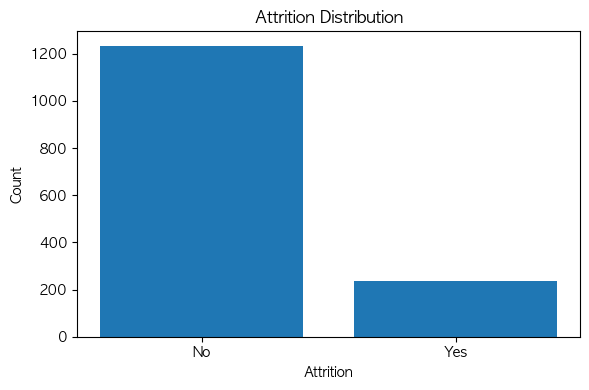


저장 완료:
eda/images/01_attrition_distribution.png


In [6]:
# 7) 시각화 코드
# 7-1. Attrition 분포

# 저장 경로
img_dir = Path("./eda/images")
img_dir.mkdir(parents=True, exist_ok=True)

# 집계
attrition_counts = df["Attrition"].value_counts()

# 시각화
plt.figure(figsize=(6, 4))
plt.bar(attrition_counts.index, attrition_counts.values)
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.tight_layout()

# 저장
plt.savefig(img_dir / "01_attrition_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

print("\n저장 완료:")
print(img_dir / "01_attrition_distribution.png")

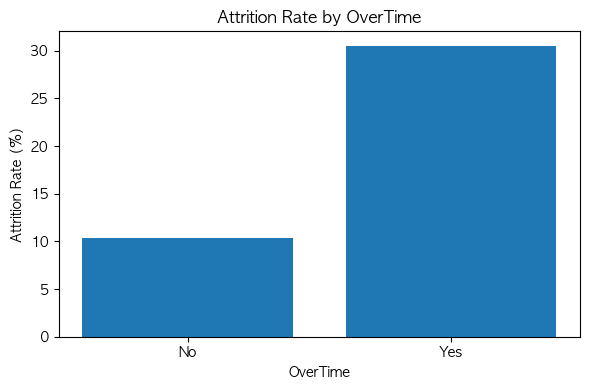


저장 완료:
eda/images/02_overtime_attrition_rate.png


In [7]:
# 7-2. OverTime에 따른 이직률

# 저장 경로
img_dir = Path("./eda/images")
img_dir.mkdir(parents=True, exist_ok=True)

# 집계
overtime_yes_rate = (pd.crosstab(df["OverTime"], df["Attrition"], normalize="index")["Yes"] * 100).round(1)

# 시각화
plt.figure(figsize=(6, 4))
plt.bar(overtime_yes_rate.index, overtime_yes_rate.values)
plt.title("Attrition Rate by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()

# 저장
plt.savefig(img_dir / "02_overtime_attrition_rate.png", dpi=180, bbox_inches="tight")
plt.show()

print("\n저장 완료:")
print(img_dir / "02_overtime_attrition_rate.png")

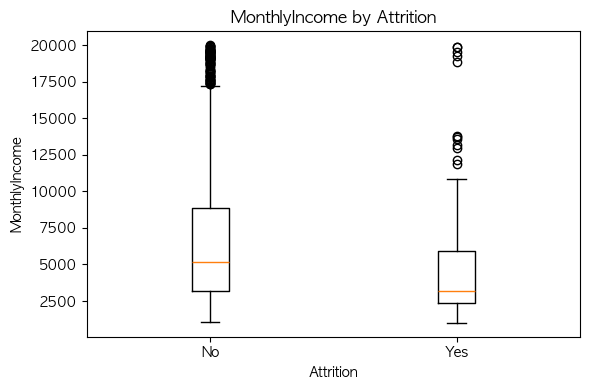


저장 완료:
eda/images/03_monthlyincome_boxplot.png


In [8]:
# 7-3. Attrition별 MonthlyIncome 박스플롯

# 저장 경로
img_dir = Path("./eda/images")
img_dir.mkdir(parents=True, exist_ok=True)

# 시각화
plt.figure(figsize=(6, 4))
plt.boxplot(
    [df[df["Attrition"] == "No"]["MonthlyIncome"],
     df[df["Attrition"] == "Yes"]["MonthlyIncome"]],
    tick_labels=["No", "Yes"]
)
plt.title("MonthlyIncome by Attrition")
plt.xlabel("Attrition")
plt.ylabel("MonthlyIncome")
plt.tight_layout()

# 저장
plt.savefig(img_dir / "03_monthlyincome_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()

print("\n저장 완료:")
print(img_dir / "03_monthlyincome_boxplot.png")

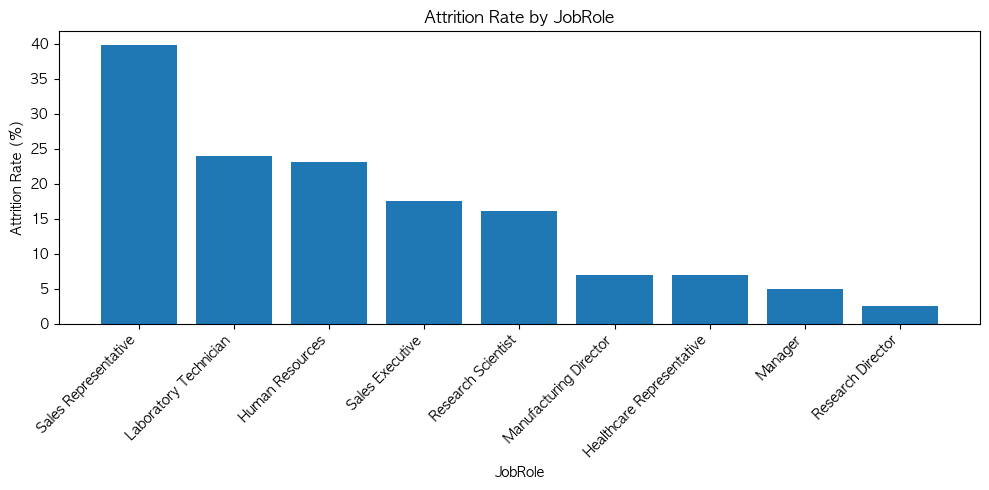


저장 완료:
eda/images/04_jobrole_attrition_rate.png


In [9]:
# 7-4. JobRole별 이직률

# 저장 경로
img_dir = Path("./eda/images")
img_dir.mkdir(parents=True, exist_ok=True)

# 집계
jobrole_yes_rate = (
    pd.crosstab(df["JobRole"], df["Attrition"], normalize="index")["Yes"] * 100
).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
plt.bar(jobrole_yes_rate.index, jobrole_yes_rate.values)
plt.title("Attrition Rate by JobRole")
plt.xlabel("JobRole")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# 저장
plt.savefig(img_dir / "04_jobrole_attrition_rate.png", dpi=180, bbox_inches="tight")
plt.show()

print("\n저장 완료:")
print(img_dir / "04_jobrole_attrition_rate.png")

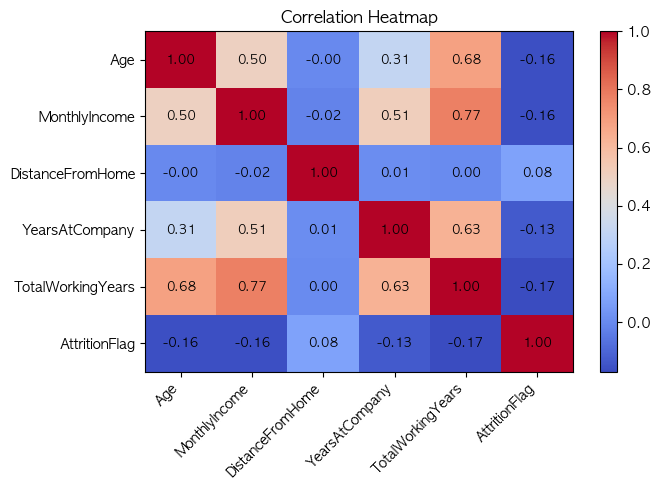


저장 완료:
eda/images/05_correlation_heatmap.png


In [10]:
# 7-5. 수치형 변수 상관관계 히트맵

# 저장 경로
img_dir = Path("./eda/images")
img_dir.mkdir(parents=True, exist_ok=True)

# 상관관계용 데이터 준비
corr_cols = ["Age", "MonthlyIncome", "DistanceFromHome", "YearsAtCompany", "TotalWorkingYears", "AttritionFlag"]

df_heat = df.copy()
df_heat["AttritionFlag"] = (df_heat["Attrition"] == "Yes").astype(int)

corr_matrix = df_heat[corr_cols].corr()

# 시각화
fig, ax = plt.subplots(figsize=(7, 5))
cax = ax.imshow(corr_matrix, cmap="coolwarm", aspect="auto")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(cax)
plt.title("Correlation Heatmap")
plt.tight_layout()

# 저장
plt.savefig(img_dir / "05_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

print("\n저장 완료:")
print(img_dir / "05_correlation_heatmap.png")